In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("gemm_sweep_staged_256_cpp.csv")

_, mb, nb, kb, avg, _, gflops = df.columns

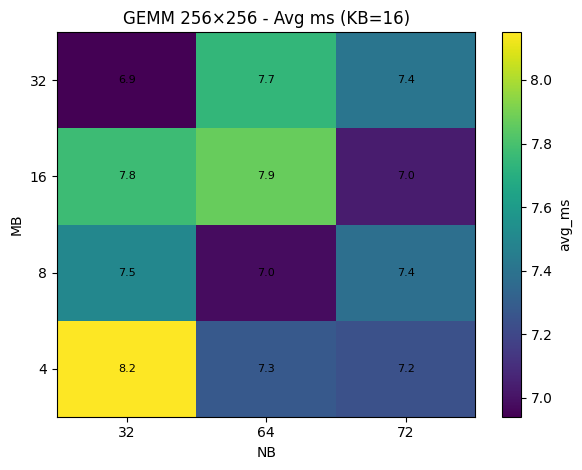

In [4]:
KB = 16
MB = [4, 8, 16, 32]
NB = [32, 64, 72]

# mb, nb, avg_ms
datapoint = [
    [4, 32, 8.15],
    [4, 64, 7.28],
    [4, 72, 7.24],
    [8, 32, 7.5],
    [8, 64, 6.98],
    [8, 72, 7.38],
    [16, 32, 7.77],
    [16, 64, 7.87],
    [16, 72, 7.03],
    [32, 32, 6.94],
    [32, 64, 7.74],
    [32, 72, 7.41],
]

# Build DataFrame
df2 = pd.DataFrame(datapoint, columns=["MB", "NB", "avg_ms"])

# Pivot into MB x NB grid and ensure full axes ordering
grid = (
    df2.pivot(index="MB", columns="NB", values="avg_ms")
      .reindex(index=MB, columns=NB)   # keep your desired order
)

data = grid.to_numpy(dtype=float)
masked = np.ma.masked_invalid(data)

# Plot
plt.figure(figsize=(6, 4.8))
im = plt.imshow(masked, origin="lower", aspect="auto")  # no custom colors per your request
plt.xticks(range(len(NB)), NB)
plt.yticks(range(len(MB)), MB)
plt.xlabel("NB")
plt.ylabel("MB")
plt.title(f"GEMM 256×256 - Avg ms (KB={KB})")
plt.colorbar(im, label="avg_ms")

# Annotate only the cells that exist
for i, mb in enumerate(MB):
    for j, nb in enumerate(NB):
        val = grid.iloc[i, j]
        if pd.notna(val):
            plt.text(j, i, f"{val:.1f}", ha="center", va="center", fontsize=8)

plt.tight_layout()
plt.show()

In [5]:
kb_vals = sorted(df[kb].unique())
data = [df.loc[df[kb] == kb_val, avg].values for kb_val in kb_vals]

/tmp/ipykernel_283205/2996384406.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=kb_vals, showfliers=False)


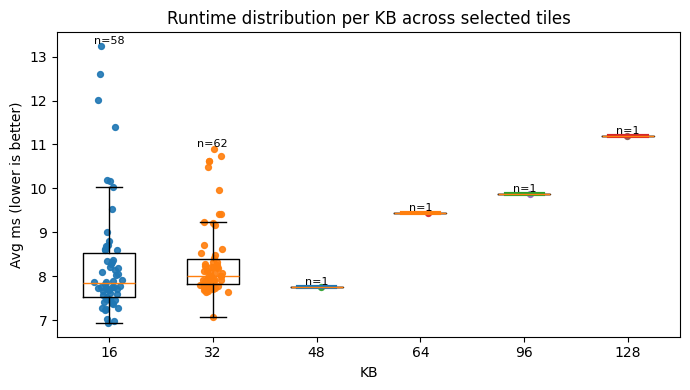

In [6]:
plt.figure(figsize=(7,4))
# 1) boxplot (will collapse to a line when n=1)
plt.boxplot(data, labels=kb_vals, showfliers=False)

for i, g in enumerate(data, start=1):
    if len(g) == 0:
        continue
    # jittered scatter of all points
    x = np.random.normal(loc=i, scale=0.06, size=len(g))
    plt.scatter(x, g, s=18, alpha=0.9)

    # show n per group
    y_top = max(g)
    plt.text(i, y_top, f"n={len(g)}", ha="center", va="bottom", fontsize=8)

    # make singletons obvious (draw a short bold bar)
    if len(g) == 1:
        plt.plot([i-0.18, i+0.18], [g[0], g[0]], linewidth=3)


plt.xlabel("KB")
plt.ylabel("Avg ms (lower is better)")
plt.title("Runtime distribution per KB across selected tiles")
plt.tight_layout()
plt.show()

In [1]:

import math
import matplotlib.pyplot as plt
import numpy as np

In [2]:
languages = ["Python", "Go", "C++", "C#"]
seq = [523.51, 87.34, 65.72,  293.07] 
openai_par = [np.nan, 13.11, 102.00, 24.93]
gemini_par = [5485.45, 51.51, 1268.12, np.nan]

def annotate_bars(ax, xs, ys, fmt="{:.3f}", fontsize=8):
    for x, y in zip(xs, ys):
        ax.text(x, y, fmt.format(y), ha="center", va="bottom", fontsize=fontsize)

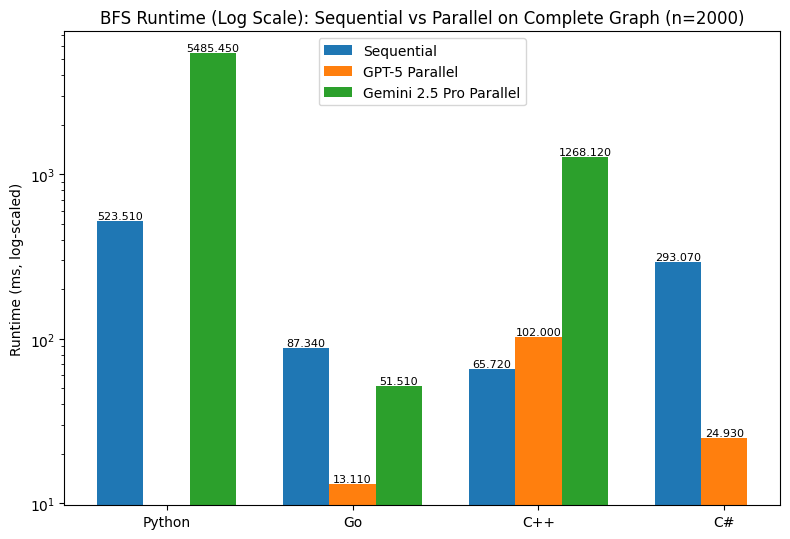

In [3]:
x = list(range(len(languages)))
width = 0.25

fig, ax = plt.subplots(figsize=(8, 5.5))
bars_seq_x     = [xi - width for xi in x]
bars_openai_x  = x
bars_gemini_x  = [xi + width for xi in x]

ax.bar(bars_seq_x, seq, width=width, label="Sequential")
ax.bar(bars_openai_x, openai_par, width=width, label="GPT-5 Parallel")
ax.bar(bars_gemini_x, gemini_par, width=width, label="Gemini 2.5 Pro Parallel")

# log scaled
ax.set_yscale("log")
ylabel = "Runtime (ms, log-scaled)"

ax.set_xticks(x, languages)
ax.set_ylabel(ylabel)
ax.set_title("BFS Runtime (Log Scale): Sequential vs Parallel on Complete Graph (n=2000)")
ax.legend()

annotate_bars(ax, bars_seq_x, seq)
annotate_bars(ax, bars_openai_x, openai_par)
annotate_bars(ax, bars_gemini_x, gemini_par)

fig.tight_layout()
plt.show()